# Project 3 - The Fake News Effect (Thaler) - Reproduction File
1. Please read in/install all necessary packages. This can be done using the first code cell.  
2. Please read the proper clean_data.csv file to run the reproduction code. This is executed in the second code cell below.

**NOTE**: Regression Tables take a while to load in!

### Reading in Packages

In [10]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

### Reading in Data

In [11]:
# df is the main dataframe for all figures and code
df = pd.read_csv("cleaned_data.csv")
# data1 is used as the primary dataframe for all regressions. It is used specifically for politicized questions in the paper.
data1 = df[df["pro_party"] + df["anti_party"] == 1].copy().reset_index(drop = True)
partisan_codes = set(df[df["pro_party"] + df["anti_party"] == 1]["code"])
data2 = df[((df["pro_party"] + df["anti_party"] + df["neutral_news"] >= 1) & (df["code"].isin(partisan_codes)))].copy().reset_index(drop = True)

### Figure 1 Code

Text(0.5, 1.0, 'Figure 1. CDF of Assessments of Pro-party and Anti-party News')

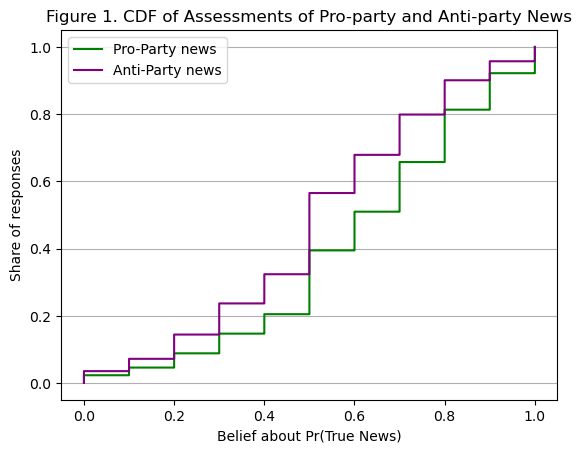

In [12]:
# sort the values and compute cumulative shares for each group
pro_vals = np.sort(df[df['pro_party'] == 1]['prob_true'])
anti_vals = np.sort(df[df['anti_party'] == 1]['prob_true'])

# y values go from 0 to 1 in equal steps
pro_y = np.arange(1, len(pro_vals) + 1) / len(pro_vals)
anti_y = np.arange(1, len(anti_vals) + 1) / len(anti_vals)

# graphing lines
plt.step(pro_vals, pro_y, label='Pro-Party news', color='green')
plt.step(anti_vals, anti_y, label='Anti-Party news', color='purple')
# graph gridlines
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.grid(axis='y')
# graph labels
plt.legend()
plt.xlabel('Belief about Pr(True News)')
plt.ylabel('Share of responses')
plt.title('Figure 1. CDF of Assessments of Pro-party and Anti-party News')

### Figure 2 Code

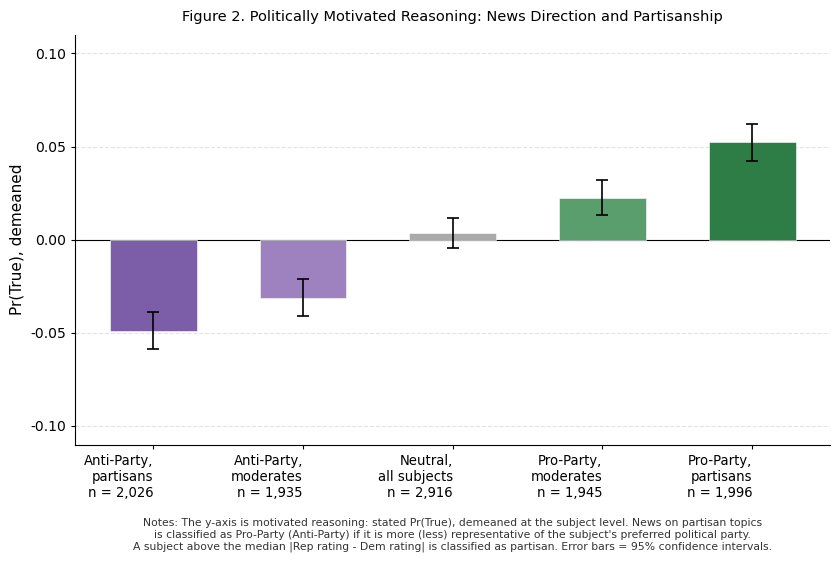

In [13]:
groups = [
    ('Anti-Party,\npartisans',   df[(df['anti_party'] == 1) & (df['partisan'] == 1)]),
    ('Anti-Party,\nmoderates',   df[(df['anti_party'] == 1) & (df['moderate'] == 1)]),
    ('Neutral,\nall subjects',   df[df['neutral_news'] == 1]),
    ('Pro-Party,\nmoderates',    df[(df['pro_party']  == 1) & (df['moderate'] == 1)]),
    ('Pro-Party,\npartisans',    df[(df['pro_party']  == 1) & (df['partisan'] == 1)]),
]

labels, means, cis, ns = [], [], [], []
for label, subset in groups:
    vals = subset['prob_true_demeaned'].dropna()
    n    = len(vals)
    m    = vals.mean()
    ci   = 1.96 * vals.std() / np.sqrt(n)    # 95% CI = 1.96 * SE
    labels.append(label)
    means.append(m)
    cis.append(ci)
    ns.append(n)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
fig.patch.set_facecolor('white')

x      = np.arange(len(labels))
colors = ['#7B5EA7', '#9E82C0', '#AAAAAA', '#5B9E6E', '#2E7D47']  # purple / grey / green

# Bars
ax.bar(x, means, color=colors, width=0.58, zorder=3,
       edgecolor='white', linewidth=0.4)

# Error bars
ax.errorbar(x, means, yerr=cis, fmt='none', color='black',
            capsize=4, capthick=1.2, linewidth=1.2, zorder=5)

# Zero reference line
ax.axhline(0, color='black', linewidth=0.8, zorder=2)

# x-axis tick labels (group name + sample size)
ax.set_xticks(x)
ax.set_xticklabels(
    [f'{lbl}\nn = {n:,}' for lbl, n in zip(labels, ns)],
    fontsize=9.5,
    rotation=0,
    ha='right',
    rotation_mode='anchor'
)
# y-axis
ax.set_ylim(-0.11, 0.11)
ax.set_yticks(np.arange(-0.10, 0.11, 0.05))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
ax.set_ylabel('Pr(True), demeaned', fontsize=11)
# Title
ax.set_title(
    'Figure 2. Politically Motivated Reasoning: News Direction and Partisanship',
    fontsize=10.5, pad=10, fontweight='normal'
)

# Notes
note = (
    'Notes: The y-axis is motivated reasoning: stated Pr(True), demeaned at the subject level. '
    'News on partisan topics\nis classified as Pro-Party (Anti-Party) if it is more (less) '
    "representative of the subject's preferred political party.\n"
    'A subject above the median |Rep rating - Dem rating| is classified as partisan. '
    'Error bars = 95% confidence intervals.'
)
fig.text(0.5, -0.18, note, ha='center', va='top', fontsize=7.8,
         color='#333333', transform=ax.transAxes)

# Spine / grid formatting
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='both', length=3, width=0.8)
ax.grid(axis='y', linestyle='--', alpha=0.35, zorder=0)

# --- 5. Save ---
plt.tight_layout()
plt.show()

### Figure 3 Code

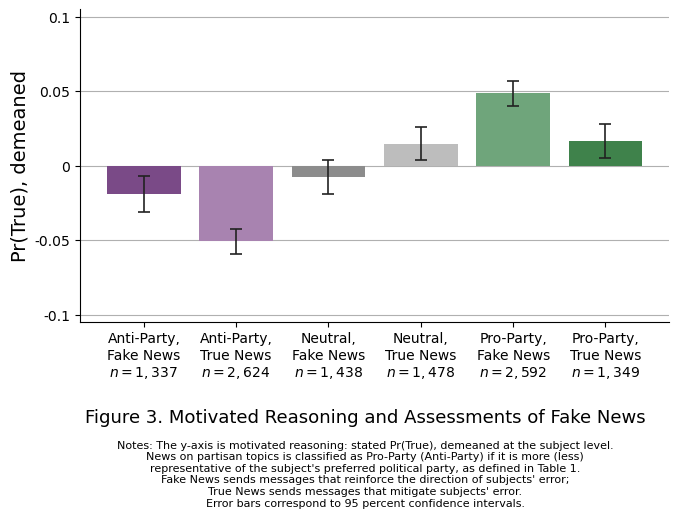

In [14]:
fig, ax = plt.subplots(figsize=(7.6, 5.9))
# drop na's
df = df[df["prob_true_demeaned"].notna()].copy()
# groups
groups = [
    ("Anti-Party,\nFake News",  (df["anti_party"] == 1) & (df["fake_news"] == 1)),
    ("Anti-Party,\nTrue News",  (df["anti_party"] == 1) & (df["true_news"] == 1)),
    ("Neutral,\nFake News",     (df["neutral_news"] == 1) & (df["fake_news"] == 1)),
    ("Neutral,\nTrue News",     (df["neutral_news"] == 1) & (df["true_news"] == 1)),
    ("Pro-Party,\nFake News",   (df["pro_party"] == 1) & (df["fake_news"] == 1)),
    ("Pro-Party,\nTrue News",   (df["pro_party"] == 1) & (df["true_news"] == 1)),
]

# empty lists
labels, means, cis, counts = [], [], [], []
for label, mask in groups:
    y    = df.loc[mask, "prob_true_demeaned"].dropna()
    n    = len(y)
    mean = y.mean()
    # building ci's
    se   = y.std(ddof=1) / np.sqrt(n)
    ci   = 1.96 * se
    labels.append(label)
    means.append(mean)
    cis.append(ci)
    counts.append(n)
means  = np.array(means)
cis    = np.array(cis)
counts = np.array(counts)

# the x-axis labels
xtick_labels = [
    f"{labels[i]}\n" + rf"$n = {counts[i]:,}$"
    for i in range(len(labels))
]
# colors from google
colors = ["#7A4A87", "#A883B0", "#8C8C8C", "#BDBDBD", "#6FA57B", "#3F824B"]
# the plot
x = np.arange(len(means))
ax.bar(x, means, color=colors)
ax.errorbar(x, means, yerr=cis, fmt='none', color="#222222", capsize=4, capthick=1.2, linewidth=1.2)
# axis labels and formatting to match paper
ax.set_ylabel("Pr(True), demeaned", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, fontsize=10)
ax.set_ylim(-0.105, 0.105)
ax.set_yticks([-0.10, -0.05, 0, 0.05, 0.10])
ax.set_yticklabels(["-0.1", "-0.05", "0", "0.05", "0.1"])
# grid & spines formatting to match paper
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# notes & caption to match paper
fig.subplots_adjust(bottom=0.35)  # adjusts the text to not overlap with the caption
fig.text(0.5, 0.18, "Figure 3. Motivated Reasoning and Assessments of Fake News", ha="center", fontsize=13)
note = """Notes: The y-axis is motivated reasoning: stated Pr(True), demeaned at the subject level.
News on partisan topics is classified as Pro-Party (Anti-Party) if it is more (less)
representative of the subject's preferred political party, as defined in Table 1.
Fake News sends messages that reinforce the direction of subjects' error;
True News sends messages that mitigate subjects' error.
Error bars correspond to 95 percent confidence intervals."""
# adjusts height of notes
fig.text(0.5, 0.15, note, ha='center', va='top', fontsize=8, wrap=True)
plt.subplots_adjust(bottom=0.35)
plt.show()

### Table 1 

In [15]:
def regression (data, formula, fe_vars, cluster_var):
    import statsmodels.formula.api as smf
    fe_terms = " + ".join([f"C({v})" for v in fe_vars])
    full_formula = f"{formula} + {fe_terms}"
    model = smf.ols(full_formula, data=data)
    fitted = model.fit()  
    groups = data.loc[model.data.row_labels, cluster_var]
    result = fitted.get_robustcov_results(cov_type='cluster', groups=groups)
    return result

spec1 = regression(data1, formula = "prob_true ~ pro_party + white + black + asian + latino + female + log_inc + edu + religious_group + red_state", fe_vars = ["topic_id", "round_number"], cluster_var="code")
spec2 = regression(data1, formula = "prob_true ~ pro_party", fe_vars = ["topic_id", "round_number", "code"], cluster_var = "code")
spec3 = regression(data1, formula= "prob_true ~ pro_party + pro_party_str + abs_net_party:C(round_number) + abs_net_party:C(topic_id)", fe_vars=["topic_id", "round_number", "code"], cluster_var="code")
spec4 = regression(data2, formula="prob_true ~ pro_party + anti_party", fe_vars=['round_number', 'code'], cluster_var='code')
spec5 = regression(data1, formula="prob_true ~ true_news", fe_vars=['topic_id', 'round_number', 'code'], cluster_var='code')
spec6 = regression(data1, formula="prob_true ~ pro_party + true_news", fe_vars=['topic_id', 'round_number', 'code'], cluster_var='code')

from statsmodels.iolib.summary2 import summary_col

# Variables to keep in output (drop FE dummies)
keep_vars = ['pro_party', 'pro_party_str', 'anti_party', 'true_news']
table = summary_col(
    [spec1, spec2, spec3, spec4, spec5, spec6],
    model_names=['(1)', '(2)', '(3)', '(4)', '(5)', '(6)'],
    stars=False,
    float_format='%.3f',
    regressor_order=keep_vars,
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs):,}",
        'R²': lambda x: f"{x.rsquared:.2f}",
        'Mean': lambda x: f"{x.model.endog.mean():.3f}",
    }
)
table.tables[0] = table.tables[0].loc[
    table.tables[0].index.str.strip().isin(keep_vars + ['N', 'R²', 'Mean', 'R-squared']) |
    (table.tables[0].index.str.strip() == '')
]
print(table)


                (1)     (2)     (3)     (4)     (5)     (6)  
-------------------------------------------------------------
pro_party     0.092   0.088   0.041   0.038           0.077  
              (0.006) (0.007) (0.013) (0.007)         (0.007)
pro_party_str                 0.099                          
                              (0.023)                        
anti_party                            -0.048                 
                                      (0.007)                
true_news                                     -0.059  -0.034 
                                              (0.006) (0.007)
R-squared     0.044   0.246   0.251   0.209   0.230   0.250  
Mean          0.574   0.574   0.574   0.575   0.574   0.574  
N             7,902   7,902   7,902   10,587  7,902   7,902  
R²            0.04    0.25    0.25    0.21    0.23    0.25   
Standard errors in parentheses.


### LaTex Entered Version of Table 1

$$
\begin{array}{l*{6}{c}}
\hline\hline
                    & (1) & (2) & (3) & (4) & (5) & (6) \\
\hline
\text{Pro-Party News}      &    0.092&    0.088&    0.041&    0.038&         &    0.077\\
                    &  (0.006)&  (0.007)&  (0.013)&  (0.007)&         &  (0.007)\\
\text{Partisanship x}      &         &         &    0.099&         &         &         \\
\text{Pro-Party}           &         &         &  (0.023)&         &         &         \\
\text{Anti-Party News}     &         &         &         &   -0.048&         &         \\
                    &         &         &         &  (0.007)&         &         \\
\text{True News}           &         &         &         &         &   -0.059&   -0.034\\
                    &         &         &         &         &  (0.006)&  (0.007)\\
\text{Question FE}         &      \text{Yes}&      \text{Yes}&      \text{Yes}&       \text{No}&      \text{Yes}&      \text{Yes}\\
\text{Round FE}            &      \text{Yes}&      \text{Yes}&      \text{Yes}&      \text{Yes}&      \text{Yes}&      \text{Yes}\\
\text{Subject FE}          &       \text{No}&      \text{Yes}&      \text{Yes}&      \text{Yes}&      \text{Yes}&      \text{Yes}\\
\text{Subject controls}    &      \text{Yes}&       \text{No}&       \text{No}&       \text{No}&       \text{No}&       \text{No}\\
\text{Neutral News}        &       \text{No}&       \text{No}&       \text{No}&      \text{Yes}&       \text{No}&       \text{No}\\
\hline
\text{Observations}        &     7902&     7902&     7902&    10552&     7902&     7902\\
R^{2}           &     0.05&     0.25&     0.25&     0.21&     0.23&     0.25\\
\text{Mean}                &    0.574&    0.574&    0.574&    0.575&    0.574&    0.574\\
\hline\hline
\text{Standard errors in parentheses} & & & & & & \\
\end{array}
$$

### Figure 4 Code

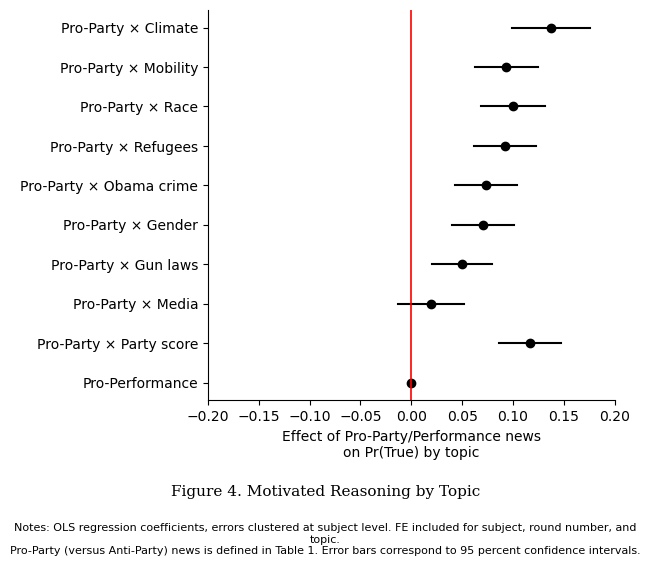

In [16]:
# Regressing each news topic on the outcome variable
spec_fig4 = regression(
    df,
    formula="prob_true ~ good_topic1 + good_topic5 + good_topic7 + good_topic2 + good_topic3 + good_topic6 + good_topic4 + good_topic8 + good_topic1415 + good_topic13",
    fe_vars=["round_number", "topic_id", "code"],
    cluster_var="code"
)

# Re-labeling each news topic to match the y-axis
labels = {"good_topic1": "Pro-Party × Climate", "good_topic7": "Pro-Party × Mobility","good_topic5": "Pro-Party × Race", "good_topic2": "Pro-Party × Refugees", "good_topic3": "Pro-Party × Obama crime", "good_topic6": "Pro-Party × Gender", "good_topic4": "Pro-Party × Gun laws", "good_topic8": "Pro-Party × Media", "good_topic1415": "Pro-Party × Party score", "good_topic13": "Pro-Performance",
}

# Placing the parameters and confidence intervals in a series and dataframe
params = pd.Series(spec_fig4.params, index=spec_fig4.model.exog_names)
cis = pd.DataFrame(spec_fig4.conf_int(), index=spec_fig4.model.exog_names)

# Plotting the coefficients
fig, ax = plt.subplots()
for i, (var, label) in enumerate(labels.items()):
    ax.plot([cis.loc[var, 0], cis.loc[var, 1]], [i, i], "k-", linewidth=1.5)
    ax.plot(params[var], i, "ko", markersize=6)

# Labeling and plotting the red line
ax.axvline(0, color="red", linewidth=1.2)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels.values())
ax.set_xlabel("Effect of Pro-Party/Performance news\non Pr(True) by topic")
ax.set_xlim(-0.2, 0.2)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.subplots_adjust(left=0.22, bottom=0.05)
fig.text(0.5, -0.02, "Figure 4. Motivated Reasoning by Topic",
         ha="center", va='top', fontsize=11, fontfamily='serif')
note = ("Notes: OLS regression coefficients, errors clustered at subject level. "
        "FE included for subject, round number, and topic.\n"
        "Pro-Party (versus Anti-Party) news is defined in Table 1. "
        "Error bars correspond to 95 percent confidence intervals.")
fig.text(0.5, -0.10, note,
         ha='center', va='top', fontsize=8, wrap=True)
plt.tight_layout()
plt.show()

### Table 3 Code

In [17]:
data3 = data1[data1["change_guess_message"].notna()].copy().reset_index(drop=True)
def regression (data, formula, fe_vars, cluster_var):
    import statsmodels.formula.api as smf
    fe_terms = " + ".join([f"C({v})" for v in fe_vars])
    full_formula = f"{formula} + {fe_terms}"
    model = smf.ols(full_formula, data=data)
    fitted = model.fit()  
    groups = data.loc[model.data.row_labels, cluster_var]
    result = fitted.get_robustcov_results(cov_type='cluster', groups=groups)
    return result

spec1 = regression(data3, formula = "change_guess_message ~ pro_party", fe_vars = ["topic_id", "round_number", "code"], cluster_var="code")
spec2 = regression(data3, formula = "change_guess_message ~ polarizing", fe_vars = ["topic_id", "round_number", "code"], cluster_var = "code")
spec3 = regression(data3, formula= "change_guess_message ~ pro_party + polarizing", fe_vars=["topic_id", "round_number", "code"], cluster_var="code")
spec4 = regression(data3, formula="change_guess_message ~ pro_party + prob_true", fe_vars=["topic_id", "round_number", "code"], cluster_var='code')
spec5 = regression(data3, formula="change_guess_message ~ polarizing + prob_true", fe_vars=['topic_id', 'round_number', 'code'], cluster_var='code')
spec6 = regression(data3, formula="change_guess_message ~ pro_party + polarizing + prob_true", fe_vars=['topic_id', 'round_number', 'code'], cluster_var='code')

from statsmodels.iolib.summary2 import summary_col

# Variables to keep in output (drop FE dummies)
keep_vars = ['pro_party', "polarizing", "prob_true"]

table = summary_col(
    [spec1, spec2, spec3, spec4, spec5, spec6],
    model_names=['(1)', '(2)', '(3)', '(4)', '(5)', '(6)'],
    stars=False,
    float_format='%.3f',
    regressor_order=keep_vars,
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs):,}",
        'R²': lambda x: f"{x.rsquared:.2f}",
        'Mean': lambda x: f"{x.model.endog.mean():.3f}",
    }
)

table.tables[0] = table.tables[0].loc[
    table.tables[0].index.str.strip().isin(keep_vars + ['N', 'R²', 'Mean', 'R-squared']) |
    (table.tables[0].index.str.strip() == '')
]
print(table)


             (1)     (2)     (3)     (4)     (5)     (6)  
----------------------------------------------------------
pro_party  0.122           0.115   0.018           0.021  
           (0.021)         (0.021) (0.018)         (0.019)
polarizing         0.060   0.034           -0.008  -0.013 
                   (0.019) (0.019)         (0.017) (0.017)
prob_true                          1.126   1.136   1.128  
                                   (0.062) (0.061) (0.063)
R-squared  0.283   0.276   0.284   0.447   0.447   0.447  
Mean       0.658   0.658   0.658   0.658   0.658   0.658  
N          4,085   4,085   4,085   4,085   4,085   4,085  
R²         0.28    0.28    0.28    0.45    0.45    0.45   
Standard errors in parentheses.


### Table 3 LaTex Output

$$
\begin{array}{l*{6}{c}}
\hline\hline
& (1) & (2) & (3) & (4) & (5) & (6) \\
\hline
\textit{Pro-Party news}  & 0.122   &         & 0.115   & 0.018   &         & 0.021   \\
                         & (0.019) &         & (0.020) & (0.017) &         & (0.018) \\
\textit{Polarizing news} &         & 0.060   & 0.034   &         & -0.008  & -0.013  \\
                         &         & (0.018) & (0.018) &         & (0.016) & (0.016) \\
\Pr(\textit{True})       &         &         &         & 1.126   & 1.136   & 1.128   \\
                         &         &         &         & (0.059) & (0.058) & (0.059) \\
\text{Question FE}       & \text{Yes} & \text{Yes} & \text{Yes} & \text{Yes} & \text{Yes} & \text{Yes} \\
\text{Round FE}          & \text{Yes} & \text{Yes} & \text{Yes} & \text{Yes} & \text{Yes} & \text{Yes} \\
\text{Subject FE}        & \text{Yes} & \text{Yes} & \text{Yes} & \text{Yes} & \text{Yes} & \text{Yes} \\
\hline
\text{Observations}      & 4{,}085 & 4{,}085 & 4{,}085 & 4{,}085 & 4{,}085 & 4{,}085 \\
R^{2}                    & 0.28    & 0.28    & 0.28    & 0.45    & 0.45    & 0.45    \\
\text{Mean}              & 0.658   & 0.658   & 0.658   & 0.658   & 0.658   & 0.658   \\
\hline\hline
\text{Standard errors in parentheses} & & & & & & \\
\end{array}
$$


### Figure 5 Code

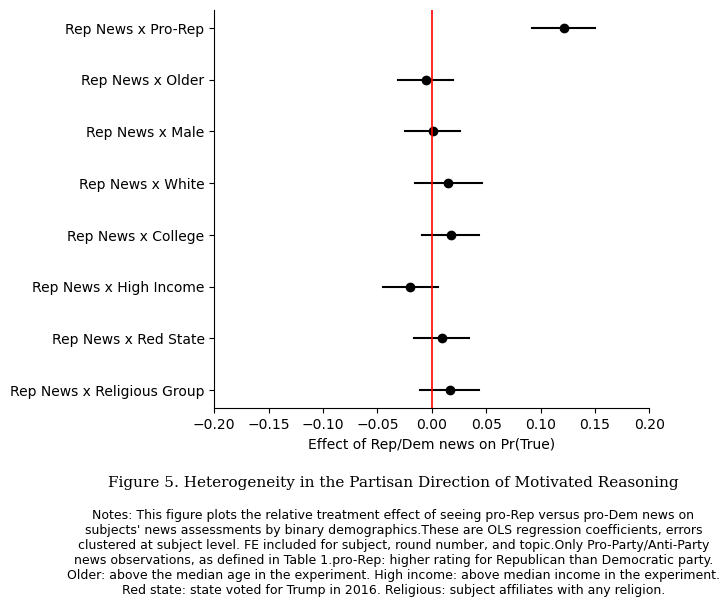

In [18]:
data1['older'] = (data1['age'] > 32).astype(int)
data1['college'] = (data1['edu'] > 13).astype(int)
data1['richer'] = (data1['inc'] >= 50000).astype(int)

for demo in ['pro_rep', 'older', 'male', 'white', 'college', 'richer', 'red_state', 'religious_group']:
    data1[f'rep_x_{demo}'] = data1['rep_news'] * data1[demo]

spec_fig5 = regression(
    data1,
    formula="prob_true ~ rep_x_pro_rep + rep_x_older + rep_x_male + rep_x_white + rep_x_college + rep_x_richer + rep_x_red_state + rep_x_religious_group + rep_news",
    fe_vars=["round_number", "topic_id", "code"],
    cluster_var="code"
)

# Re-labeling each news topic to match the y-axis
labels = {"rep_x_pro_rep": "Rep News x Pro-Rep",
    "rep_x_older": "Rep News x Older",
    "rep_x_male": "Rep News x Male",
    "rep_x_white": "Rep News x White",
    "rep_x_college": "Rep News x College",
    "rep_x_richer": "Rep News x High Income",
    "rep_x_red_state": "Rep News x Red State",
    "rep_x_religious_group": "Rep News x Religious Group",
}

# Placing the parameters and confidence intervals in a series and dataframe
params = pd.Series(spec_fig5.params, index=spec_fig5.model.exog_names)
cis = pd.DataFrame(spec_fig5.conf_int(), index=spec_fig5.model.exog_names)

# Plotting the coefficients
fig, ax = plt.subplots()
for i, (var, label) in enumerate(labels.items()):
    ax.plot([cis.loc[var, 0], cis.loc[var, 1]], [i, i], "k-", linewidth=1.5)
    ax.plot(params[var], i, "ko", markersize=6)

# Labeling and plotting the red line
ax.axvline(0, color="red", linewidth=1.2)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels.values())
ax.set_xlabel("Effect of Rep/Dem news on Pr(True)")
ax.set_xlim(-0.2, 0.2)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.text(0.5, -0.09, "Figure 5. Heterogeneity in the Partisan Direction of Motivated Reasoning",
         ha="center", va='top', fontsize=11, fontfamily='serif')

note = ("Notes: This figure plots the relative treatment effect of seeing pro-Rep versus pro-Dem news on subjects' news assessments by binary demographics."
        "These are OLS regression coefficients, errors clustered at subject level. FE included for subject, round number, and topic." 
        "Only Pro-Party/Anti-Party news observations, as defined in Table 1."
        "pro-Rep: higher rating for Republican than Democratic party. Older: above the median age in the experiment. High "
        "income: above median income in the experiment. Red state: state voted for Trump in 2016. Religious: subject "
        "affiliates with any religion.")

fig.text(0.5, -0.16, note,
         ha='center', va='top', fontsize=9, wrap=True)

plt.subplots_adjust(left=0.22, bottom=0.05)
plt.savefig("figure5_replication.png", dpi=200, bbox_inches="tight")
plt.show()